# EF-02 | Financial News Sentiment Analyser — Visualization & Analysis
**BSc DSAI | Tanzania Financial Sector Projects | 2025/2026**

This notebook visualizes and analyses the relationship between Tanzanian financial news sentiment and key macroeconomic indicators (CPI Inflation & USD/TZS Exchange Rate) for the period **January 2022 – November 2024**.

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries loaded ✔')

Libraries loaded ✔


## 1. Load & Prepare Data

In [4]:
df = pd.read_csv('data/Visualization_Data.csv')

# Parse date column
df['YearMonth'] = pd.to_datetime(df['YearMonth'], format='%Y-%m')
df = df.sort_values('YearMonth').reset_index(drop=True)

# Rename for convenience
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Negative %': 'Negative',
    'Neutral %':  'Neutral',
    'Positive %': 'Positive',
    'Inflation %': 'Inflation',
    'USD/TZS_Rate': 'ExchRate',
    'Rate_Change_%': 'ExchChange'
})

# Sentiment score: weighted index  (-1 × Neg  +  0 × Neu  +  1 × Pos) / 100
df['SentimentScore'] = (df['Positive'] - df['Negative']) / 100

# Yearly period for grouping
df['Year'] = df['YearMonth'].dt.year

df[['YearMonth','num_headlines','Positive','Neutral','Negative','SentimentScore','Inflation','ExchRate']].head(6)

,YearMonth,num_headlines,Positive,Neutral,Negative,SentimentScore,Inflation,ExchRate
0,2022-01-01,43,20.93,62.79,16.28,0.0465,3.997044,2303.380952
1,2022-02-01,33,30.30,60.61,9.09,0.2121,3.673581,2308.800000
2,2022-03-01,45,20.00,71.11,8.89,0.1111,3.552367,2312.565217
3,2022-04-01,41,36.59,46.34,17.07,0.1952,3.783246,2317.761905
4,2022-05-01,44,43.18,40.91,15.91,0.2727,4.026812,2320.818182
5,2022-06-01,60,21.67,70.00,8.33,0.1334,4.436698,2326.090909


## 2. Dataset Overview — Coverage & Sentiment Distribution

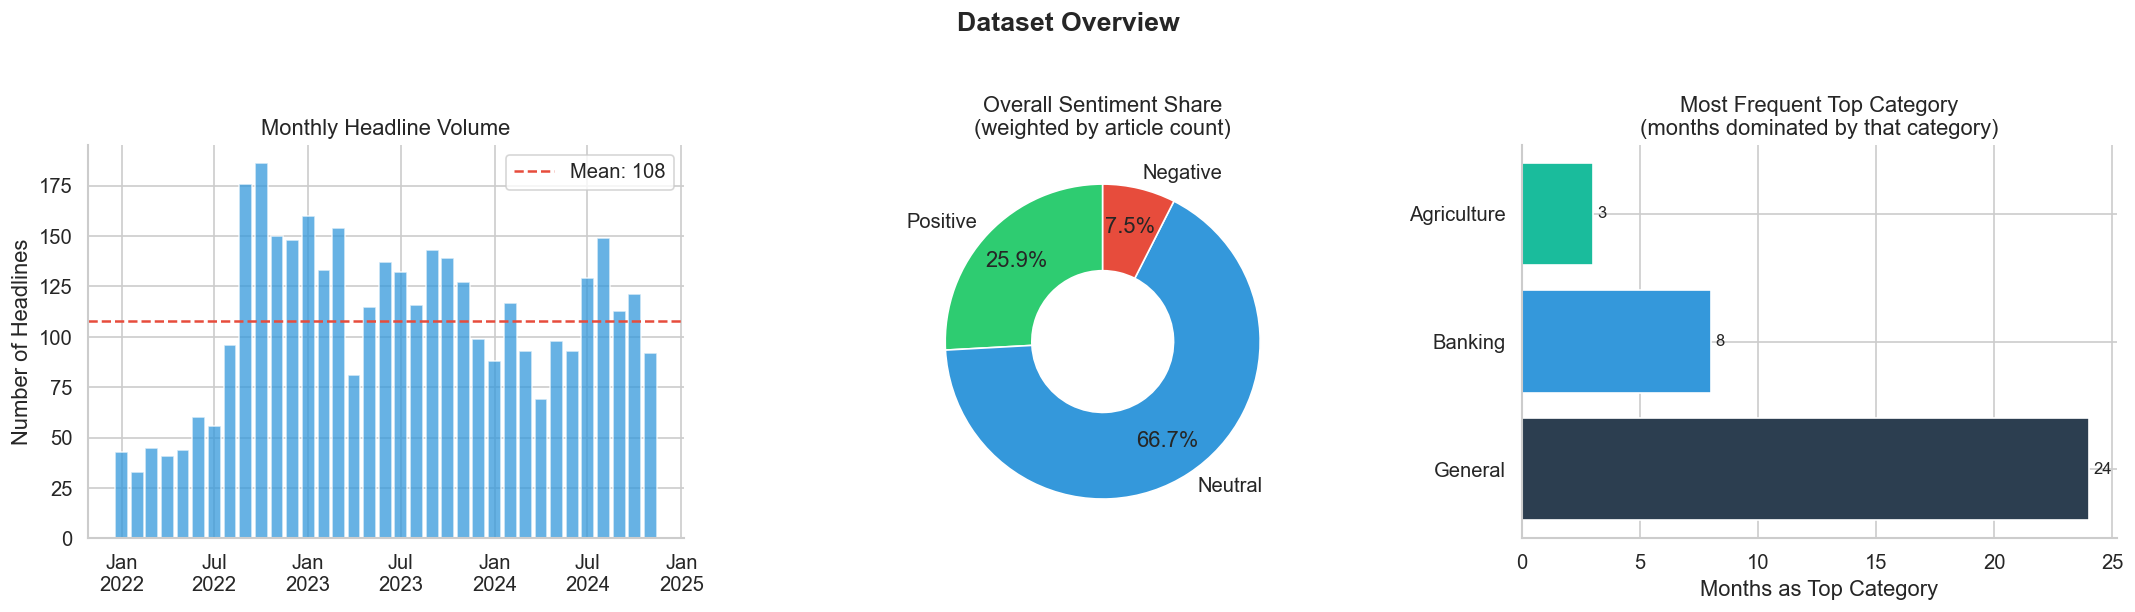


⚠  Neutral dominates 34/35 months — only 1 months have a non-neutral dominant sentiment.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', y=1.02)

# ── 2a. Monthly headline count ─────────────────────────────────────────────
ax = axes[0]
ax.bar(df['YearMonth'], df['num_headlines'],
       color='#3498db', alpha=0.75, width=25, edgecolor='white')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.set_title('Monthly Headline Volume')
ax.set_ylabel('Number of Headlines')
ax.axhline(df['num_headlines'].mean(), color='#e74c3c',
           ls='--', lw=1.5, label=f'Mean: {df["num_headlines"].mean():.0f}')
ax.legend()

# ── 2b. Overall sentiment breakdown (pie) ─────────────────────────────────
ax = axes[1]
totals = {
    'Positive': (df['Positive'] * df['num_headlines'] / 100).sum(),
    'Neutral':  (df['Neutral']  * df['num_headlines'] / 100).sum(),
    'Negative': (df['Negative'] * df['num_headlines'] / 100).sum()
}
wedge_props = dict(width=0.55)
ax.pie(totals.values(), labels=totals.keys(),
       colors=[PALETTE[k] for k in totals.keys()],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=wedge_props, pctdistance=0.75)
ax.set_title('Overall Sentiment Share\n(weighted by article count)')

# ── 2c. Dominant category frequency ───────────────────────────────────────
ax = axes[2]
cat_counts = df['Top_Category'].value_counts()
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=['#2c3e50','#3498db','#1abc9c','#9b59b6','#e67e22'][:len(cat_counts)],
               edgecolor='white')
ax.set_title('Most Frequent Top Category\n(months dominated by that category)')
ax.set_xlabel('Months as Top Category')
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig01_overview.png', bbox_inches='tight')
plt.show()

print(f"\n⚠  Neutral dominates {(df['Dominant_Sentiment']=='Neutral').sum()}/{len(df)} months — "
      f"only {(df['Dominant_Sentiment']!='Neutral').sum()} months have a non-neutral dominant sentiment.")

## 3. Sentiment Trend Over Time

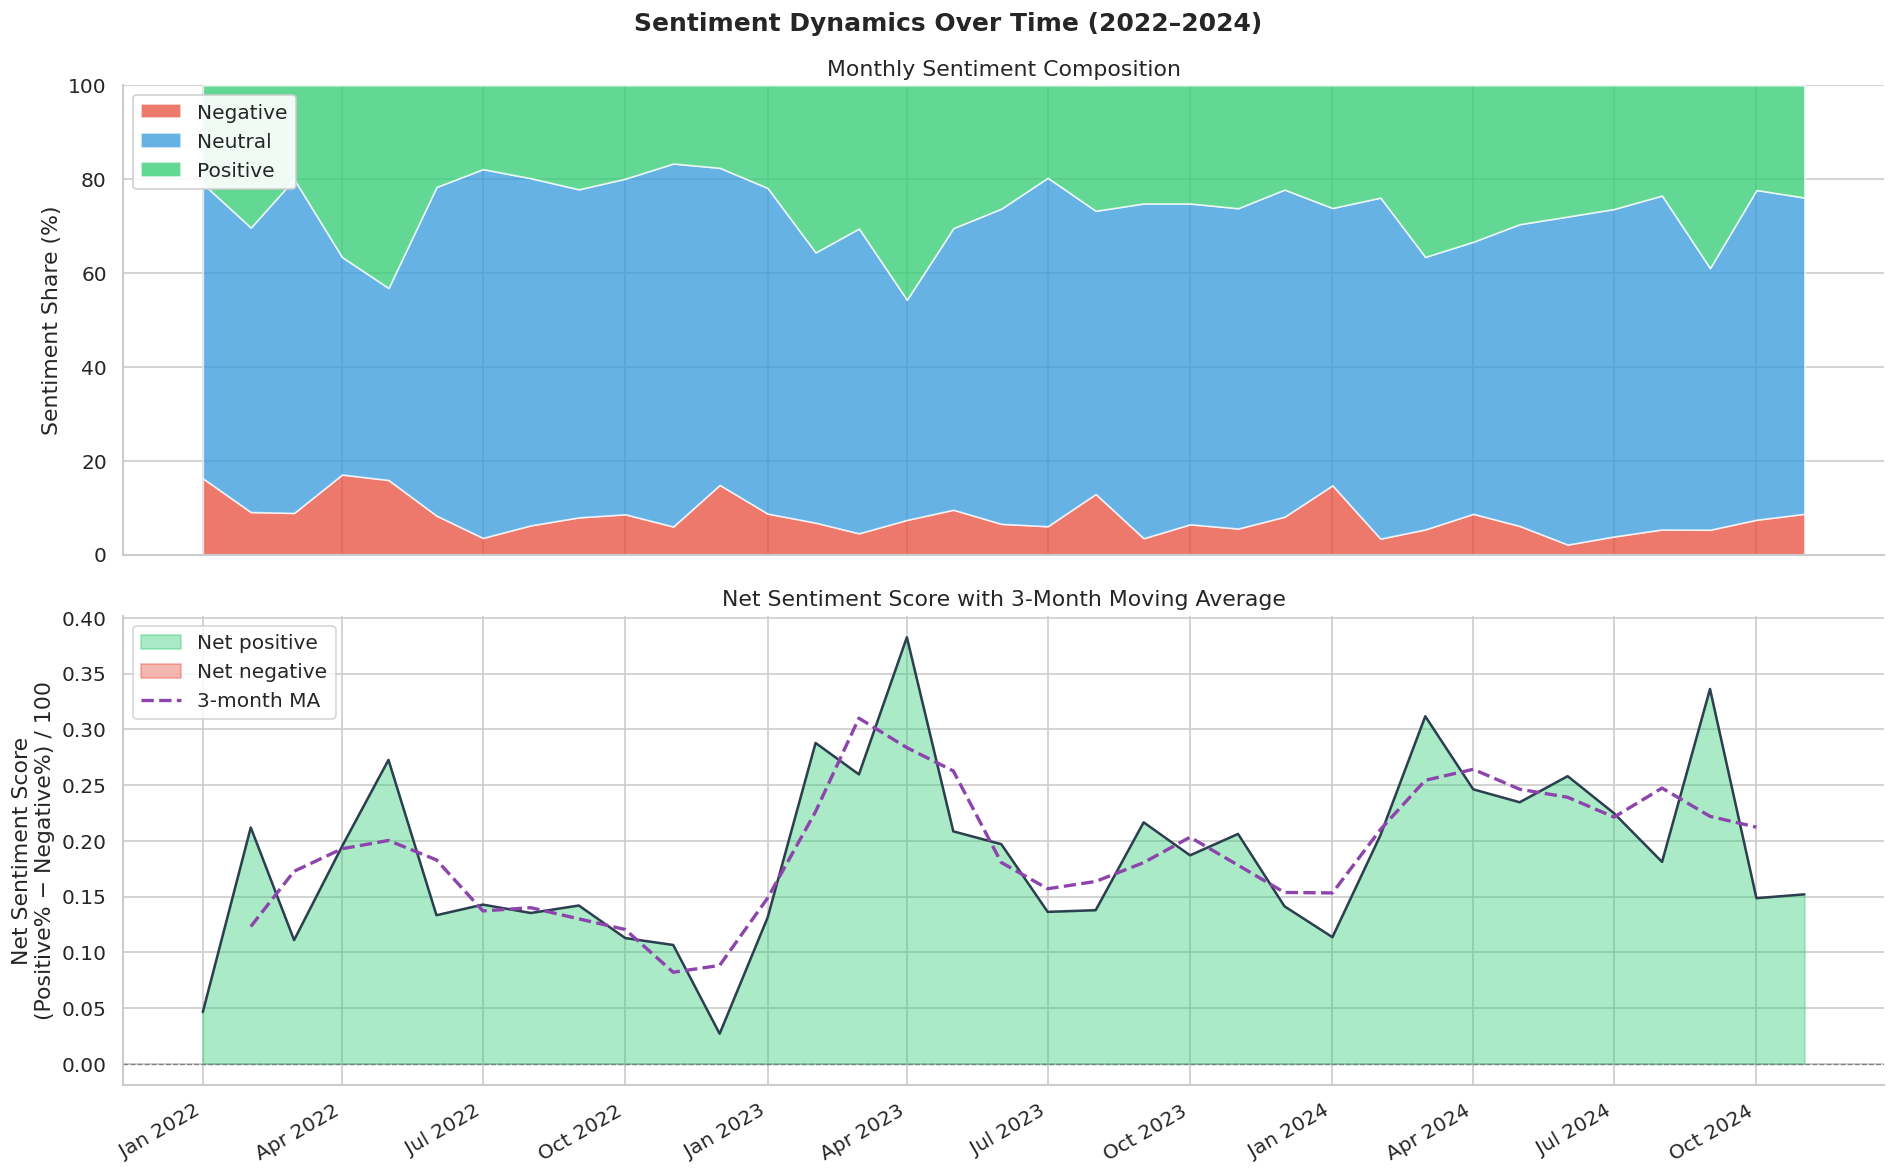

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Sentiment Dynamics Over Time (2022–2024)',
             fontsize=15, fontweight='bold')

# ── 3a. Stacked area: sentiment breakdown ─────────────────────────────────
ax = axes[0]
ax.stackplot(df['YearMonth'],
             df['Negative'], df['Neutral'], df['Positive'],
             labels=['Negative', 'Neutral', 'Positive'],
             colors=[PALETTE['Negative'], PALETTE['Neutral'], PALETTE['Positive']],
             alpha=0.75)
ax.set_ylabel('Sentiment Share (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', framealpha=0.9)
ax.set_title('Monthly Sentiment Composition')

# ── 3b. Sentiment score (net) ─────────────────────────────────────────────
ax = axes[1]
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.fill_between(df['YearMonth'], df['SentimentScore'],
                where=df['SentimentScore'] >= 0,
                color=PALETTE['Positive'], alpha=0.4, label='Net positive')
ax.fill_between(df['YearMonth'], df['SentimentScore'],
                where=df['SentimentScore'] < 0,
                color=PALETTE['Negative'], alpha=0.4, label='Net negative')
ax.plot(df['YearMonth'], df['SentimentScore'],
        color='#2c3e50', lw=1.5)

# Rolling 3-month average
df['SentScore_MA3'] = df['SentimentScore'].rolling(3, center=True).mean()
ax.plot(df['YearMonth'], df['SentScore_MA3'],
        color='#8e44ad', lw=2, ls='--', label='3-month MA')

ax.set_ylabel('Net Sentiment Score\n(Positive% − Negative%) / 100')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.set_title('Net Sentiment Score with 3-Month Moving Average')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig02_sentiment_trend.png', bbox_inches='tight')
plt.show()

## 4. Macroeconomic Indicators Over Time

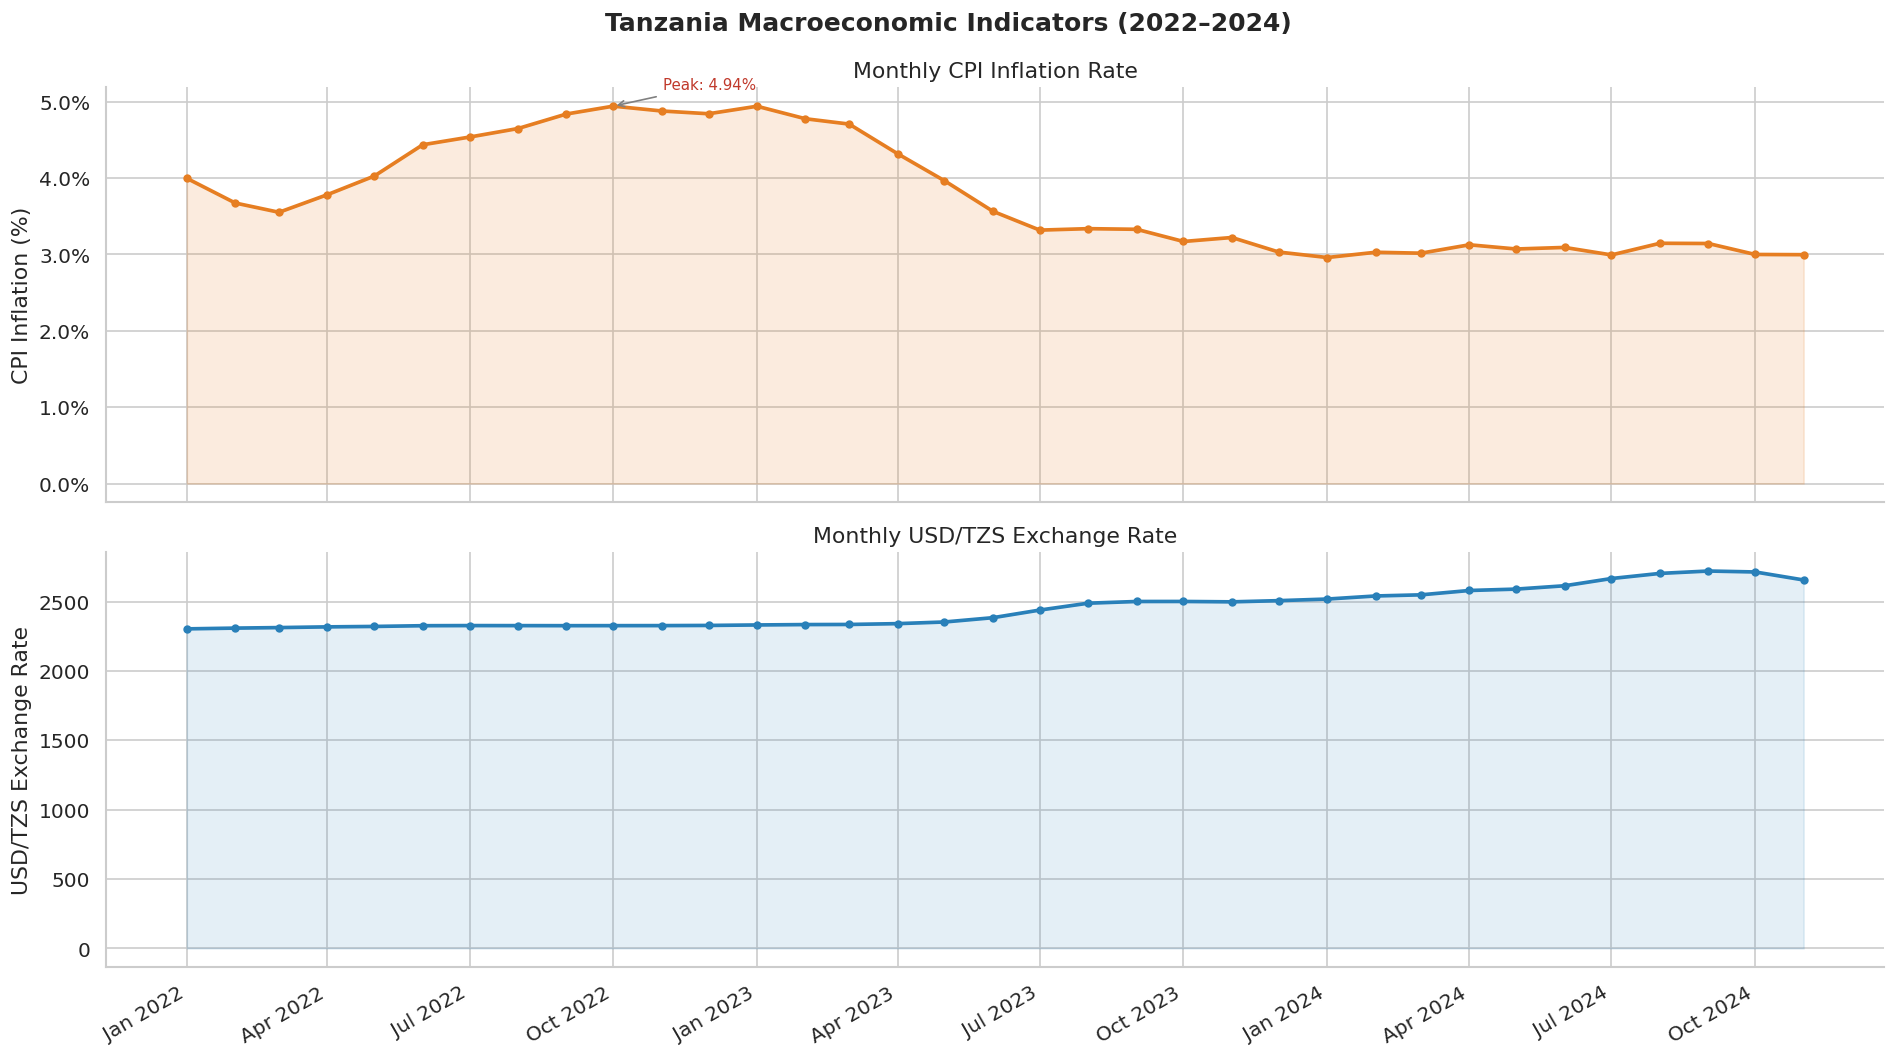

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Tanzania Macroeconomic Indicators (2022–2024)',
             fontsize=15, fontweight='bold')

# ── 4a. CPI Inflation ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['YearMonth'], df['Inflation'],
        color='#e67e22', lw=2.2, marker='o', markersize=4)
ax.fill_between(df['YearMonth'], df['Inflation'],
                alpha=0.15, color='#e67e22')
ax.set_ylabel('CPI Inflation (%)')
ax.set_title('Monthly CPI Inflation Rate')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Annotate peak
peak_idx = df['Inflation'].idxmax()
ax.annotate(f"Peak: {df.loc[peak_idx,'Inflation']:.2f}%",
            xy=(df.loc[peak_idx,'YearMonth'], df.loc[peak_idx,'Inflation']),
            xytext=(30, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='#c0392b')

# ── 4b. USD/TZS Exchange Rate ──────────────────────────────────────────────
ax = axes[1]
ax.plot(df['YearMonth'], df['ExchRate'],
        color='#2980b9', lw=2.2, marker='o', markersize=4)
ax.fill_between(df['YearMonth'], df['ExchRate'],
                alpha=0.12, color='#2980b9')
ax.set_ylabel('USD/TZS Exchange Rate')
ax.set_title('Monthly USD/TZS Exchange Rate')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig03_macro_indicators.png', bbox_inches='tight')
plt.show()

## 5. Sentiment vs. Macroeconomic Indicators — Overlay & Correlation

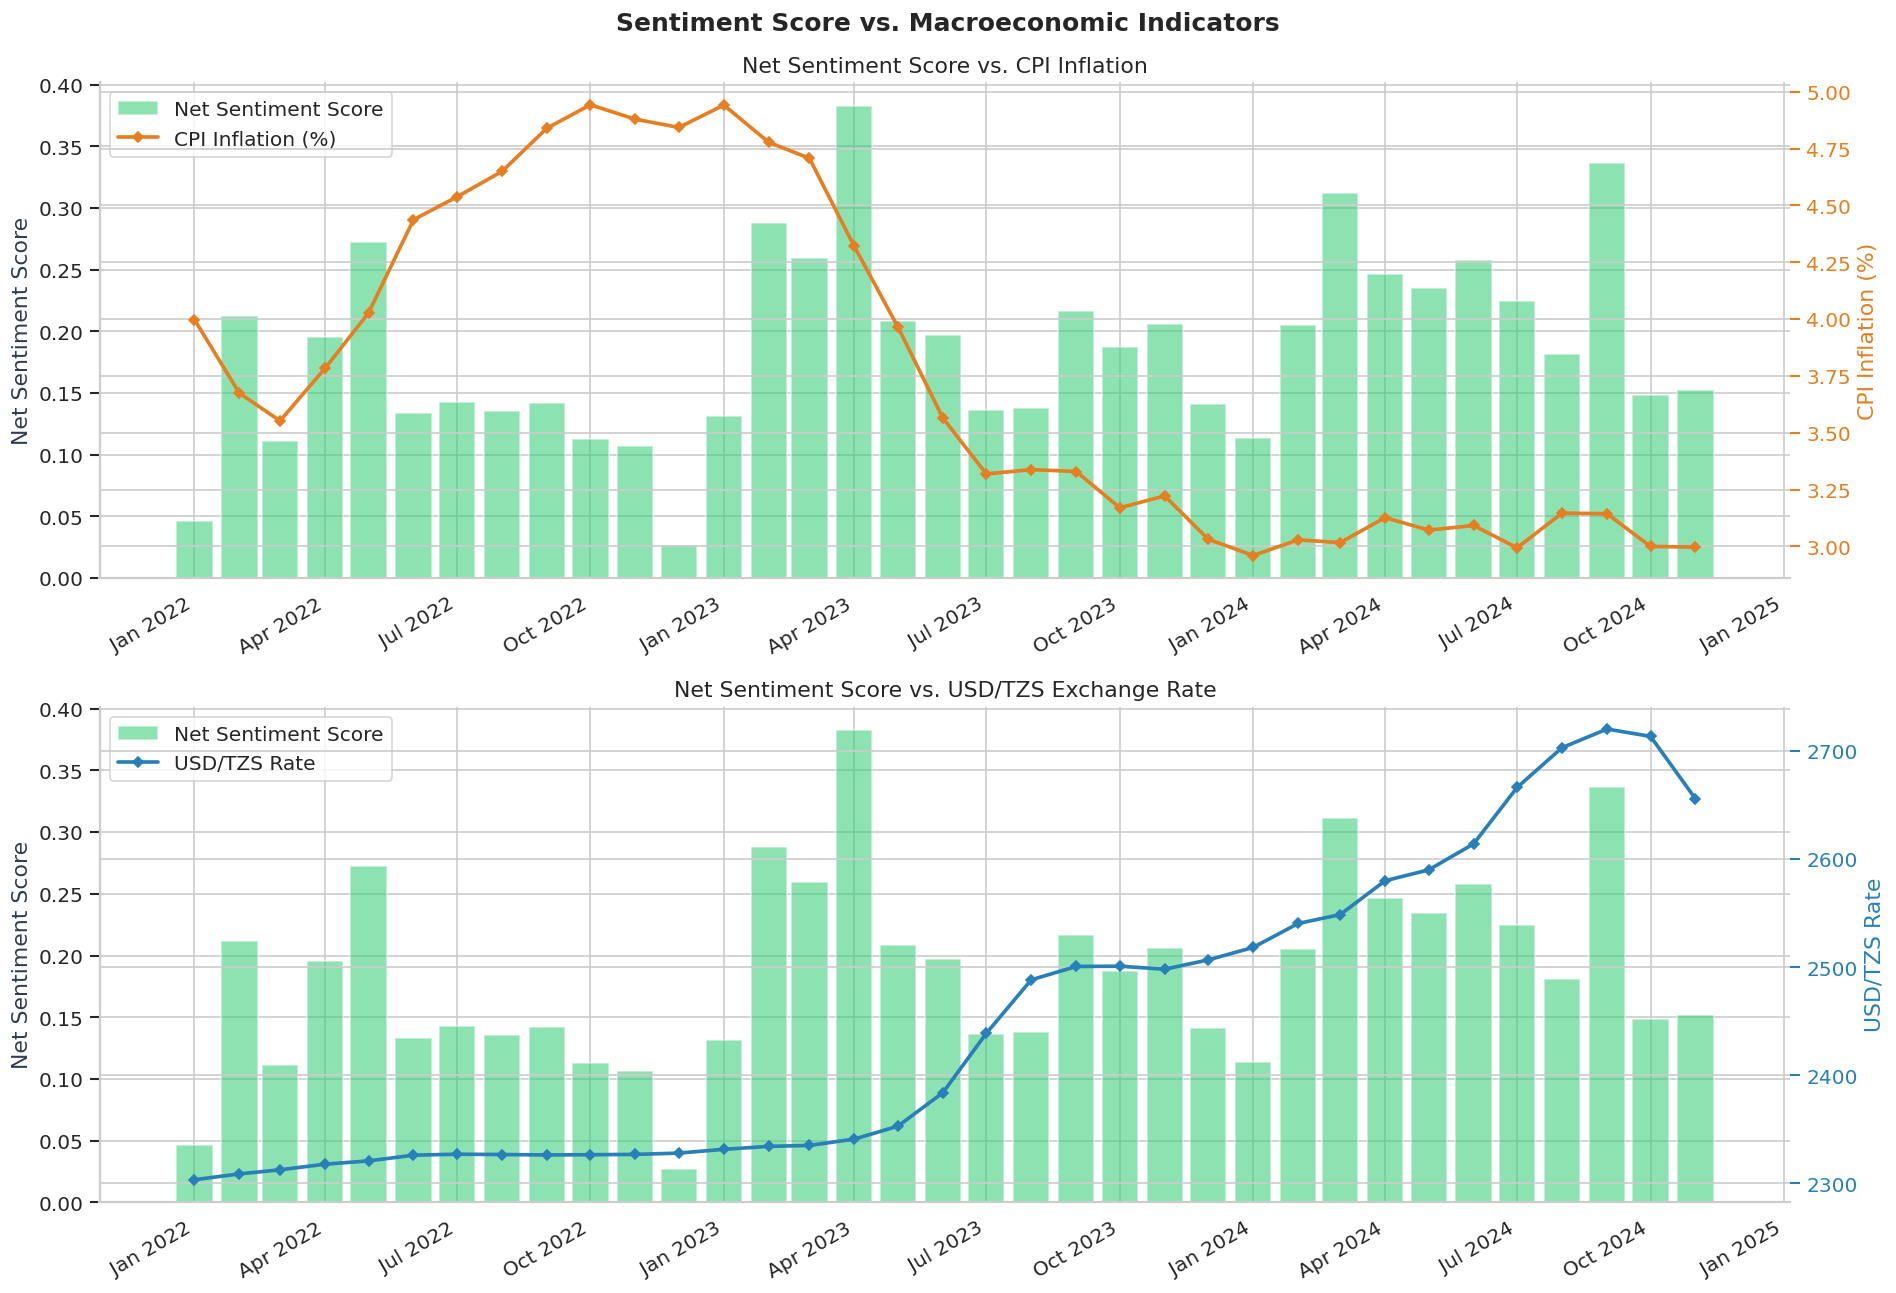

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('Sentiment Score vs. Macroeconomic Indicators',
             fontsize=15, fontweight='bold')

def dual_axis_plot(ax, df, y2_col, y2_label, y2_color, title):
    ax2 = ax.twinx()
    ax.bar(df['YearMonth'], df['SentimentScore'],
           width=25, alpha=0.55,
           color=np.where(df['SentimentScore'] >= 0,
                          PALETTE['Positive'], PALETTE['Negative']),
           label='Net Sentiment Score')
    ax2.plot(df['YearMonth'], df[y2_col],
             color=y2_color, lw=2.2, marker='D',
             markersize=4, label=y2_label)
    ax.set_ylabel('Net Sentiment Score', color='#2c3e50')
    ax2.set_ylabel(y2_label, color=y2_color)
    ax2.tick_params(axis='y', colors=y2_color)
    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    return ax2

dual_axis_plot(axes[0], df, 'Inflation', 'CPI Inflation (%)',
               '#e67e22',
               'Net Sentiment Score vs. CPI Inflation')

dual_axis_plot(axes[1], df, 'ExchRate', 'USD/TZS Rate',
               '#2980b9',
               'Net Sentiment Score vs. USD/TZS Exchange Rate')

plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig04_sentiment_vs_macro.png', bbox_inches='tight')
plt.show()

## 6. Lag Correlation Analysis
Does sentiment *lead* or *follow* macroeconomic changes?

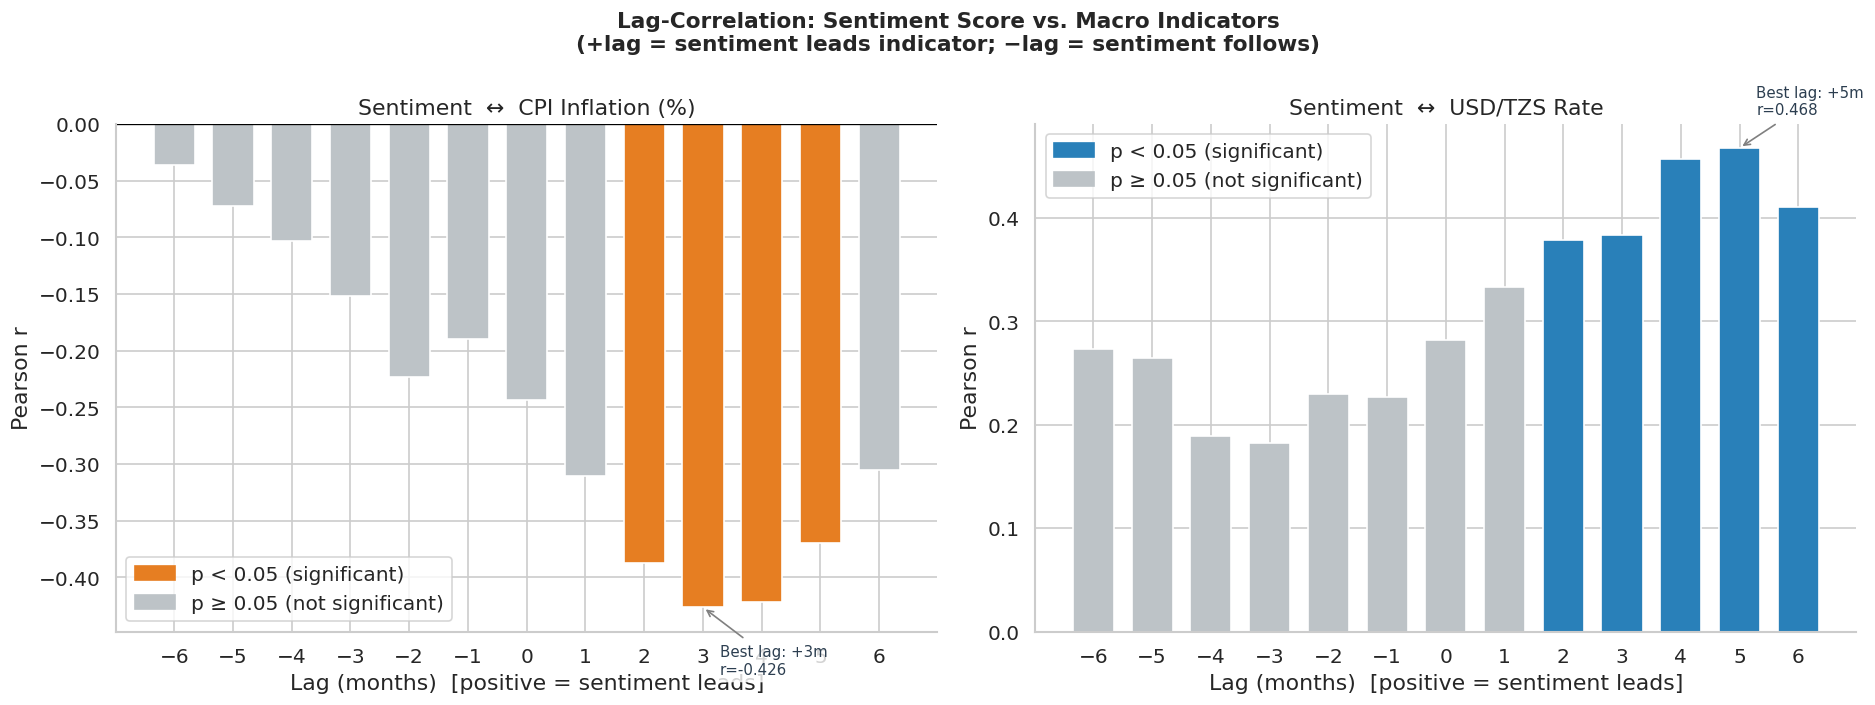


Lag-correlation table:
 lag  r_inflation  p_inflation  r_exch  p_exch
  -6       -0.036       +0.853  +0.273  +0.152
  -5       -0.072       +0.705  +0.265  +0.157
  -4       -0.103       +0.580  +0.189  +0.308
  -3       -0.152       +0.407  +0.183  +0.317
  -2       -0.223       +0.212  +0.230  +0.199
  -1       -0.190       +0.281  +0.227  +0.197
   0       -0.244       +0.158  +0.282  +0.101
   1       -0.311       +0.074  +0.333  +0.054
   2       -0.388       +0.026  +0.379  +0.030
   3       -0.426       +0.015  +0.383  +0.030
   4       -0.421       +0.018  +0.457  +0.010
   5       -0.370       +0.044  +0.468  +0.009
   6       -0.305       +0.107  +0.410  +0.027


In [7]:
# Compute Pearson r at various lags  (-6 to +6 months)
# Positive lag: sentiment LEADS the indicator
# Negative lag: sentiment LAGS the indicator

lags = range(-6, 7)
results = {'lag': [], 'r_inflation': [], 'p_inflation': [],
           'r_exch': [], 'p_exch': []}

for lag in lags:
    sentiment = df['SentimentScore']
    infl  = df['Inflation'].shift(-lag)   # shift indicator backward = sentiment leads
    exch  = df['ExchRate'].shift(-lag)

    valid_i = sentiment.notna() & infl.notna()
    valid_e = sentiment.notna() & exch.notna()

    r_i, p_i = pearsonr(sentiment[valid_i], infl[valid_i])
    r_e, p_e = pearsonr(sentiment[valid_e], exch[valid_e])

    results['lag'].append(lag)
    results['r_inflation'].append(r_i)
    results['p_inflation'].append(p_i)
    results['r_exch'].append(r_e)
    results['p_exch'].append(p_e)

lag_df = pd.DataFrame(results)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lag-Correlation: Sentiment Score vs. Macro Indicators\n'
             '(+lag = sentiment leads indicator; −lag = sentiment follows)',
             fontsize=13, fontweight='bold')

for ax, col, pcol, label, color in [
    (axes[0], 'r_inflation', 'p_inflation', 'CPI Inflation (%)', '#e67e22'),
    (axes[1], 'r_exch',      'p_exch',      'USD/TZS Rate',      '#2980b9')
]:
    bars = ax.bar(lag_df['lag'], lag_df[col],
                  color=[color if p < 0.05 else '#bdc3c7'
                         for p in lag_df[pcol]],
                  edgecolor='white', width=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(list(lags))
    ax.set_xlabel('Lag (months)  [positive = sentiment leads]')
    ax.set_ylabel("Pearson r")
    ax.set_title(f'Sentiment  ↔  {label}')

    # Mark best lag
    best_lag_idx = lag_df[col].abs().idxmax()
    best_lag = lag_df.loc[best_lag_idx, 'lag']
    best_r   = lag_df.loc[best_lag_idx, col]
    ax.annotate(f'Best lag: {best_lag:+d}m\nr={best_r:.3f}',
                xy=(best_lag, best_r),
                xytext=(10, 20 if best_r > 0 else -40),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # Legend for significance
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color=color, label='p < 0.05 (significant)'),
        Patch(color='#bdc3c7', label='p ≥ 0.05 (not significant)')
    ])

plt.tight_layout()
plt.savefig('fig05_lag_correlation.png', bbox_inches='tight')
plt.show()

print('\nLag-correlation table:')
print(lag_df.to_string(index=False, float_format=lambda x: f'{x:+.3f}'))

## 7. Category Analysis — Does Topic Mix Signal Economic Tone?

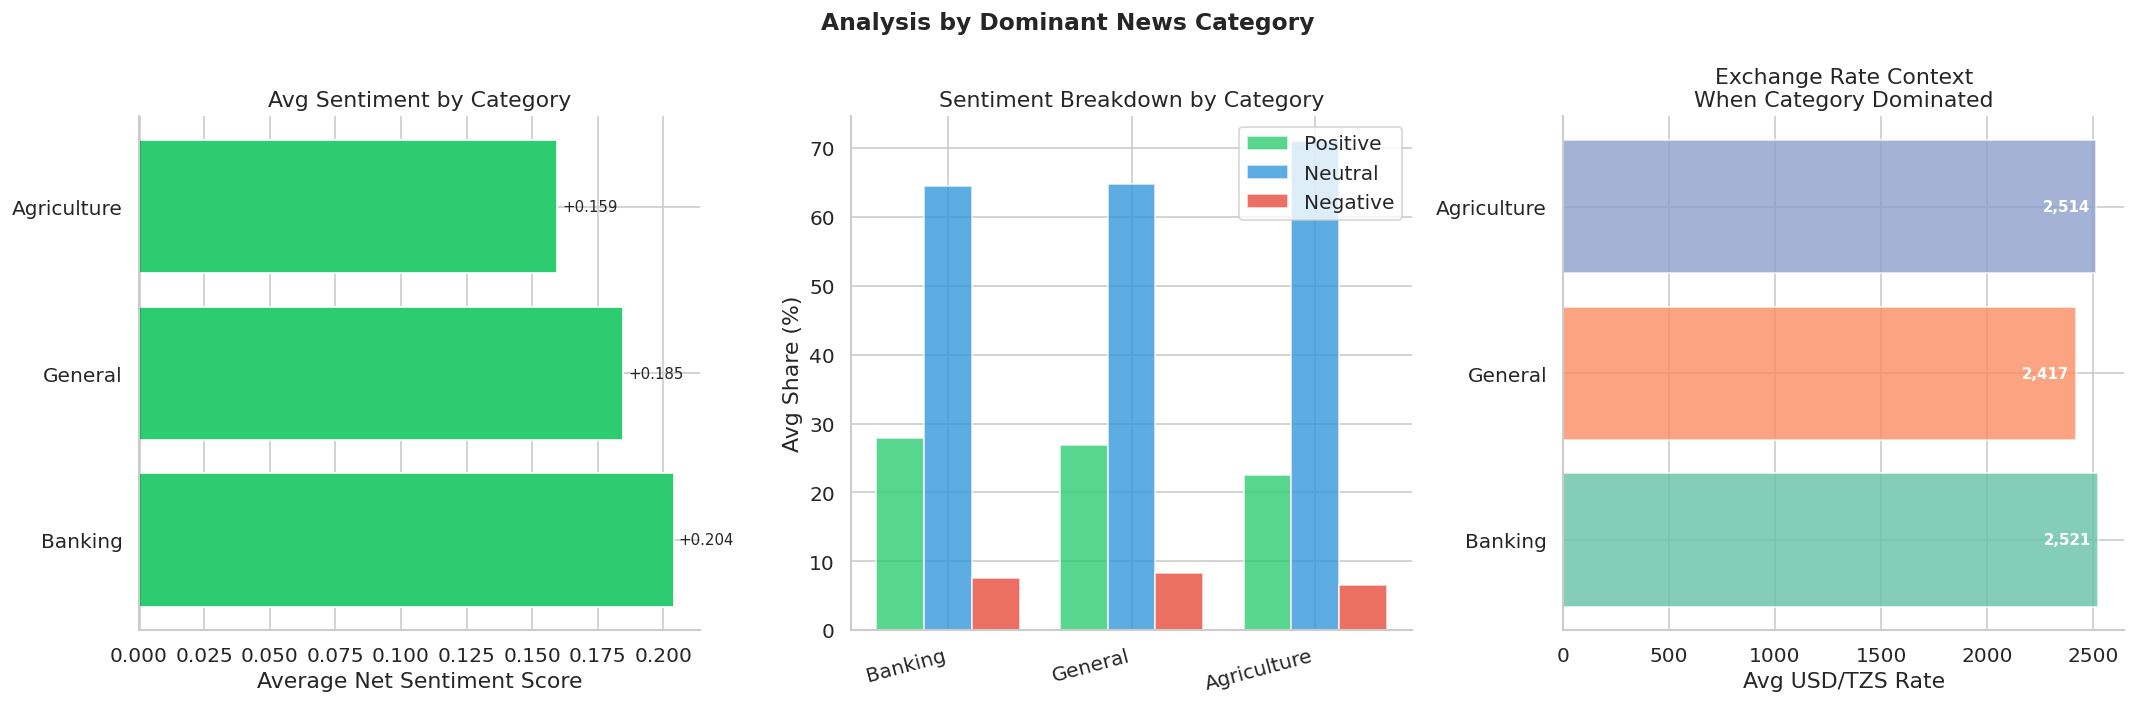

Top_Category  months  avg_sentiment  avg_inflation  avg_exch
     Banking       8          0.204          3.399  2520.763
     General      24          0.185          3.873  2416.927
 Agriculture       3          0.159          3.757  2513.556


In [8]:
# Average sentiment score and macro indicators per dominant category
cat_stats = df.groupby('Top_Category').agg(
    months=('YearMonth', 'count'),
    avg_sentiment=('SentimentScore', 'mean'),
    avg_inflation=('Inflation', 'mean'),
    avg_exch=('ExchRate', 'mean'),
    avg_positive=('Positive', 'mean'),
    avg_neutral=('Neutral', 'mean'),
    avg_negative=('Negative', 'mean')
).reset_index().sort_values('avg_sentiment', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analysis by Dominant News Category', fontsize=14, fontweight='bold')

cats = cat_stats['Top_Category']
colors_cat = sns.color_palette('Set2', len(cats))

# ── 7a. Avg sentiment score per category ──────────────────────────────────
ax = axes[0]
bars = ax.barh(cats, cat_stats['avg_sentiment'],
               color=[PALETTE['Positive'] if v >= 0 else PALETTE['Negative']
                      for v in cat_stats['avg_sentiment']])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Average Net Sentiment Score')
ax.set_title('Avg Sentiment by Category')
for bar, val in zip(bars, cat_stats['avg_sentiment']):
    ax.text(val + 0.002 if val >= 0 else val - 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# ── 7b. Grouped bar: sentiment breakdown per category ─────────────────────
ax = axes[1]
x = np.arange(len(cats))
w = 0.26
ax.bar(x - w, cat_stats['avg_positive'], w, label='Positive', color=PALETTE['Positive'], alpha=0.8)
ax.bar(x,     cat_stats['avg_neutral'],  w, label='Neutral',  color=PALETTE['Neutral'],  alpha=0.8)
ax.bar(x + w, cat_stats['avg_negative'], w, label='Negative', color=PALETTE['Negative'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=15, ha='right')
ax.set_ylabel('Avg Share (%)')
ax.set_title('Sentiment Breakdown by Category')
ax.legend()

# ── 7c. Avg USD/TZS when each category dominated ──────────────────────────
ax = axes[2]
ax.barh(cats, cat_stats['avg_exch'],
        color=colors_cat, alpha=0.8, edgecolor='white')
ax.set_xlabel('Avg USD/TZS Rate')
ax.set_title('Exchange Rate Context\nWhen Category Dominated')
for bar, val in zip(ax.patches, cat_stats['avg_exch']):
    ax.text(val - 30, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fig06_category_analysis.png', bbox_inches='tight')
plt.show()

print(cat_stats[['Top_Category','months','avg_sentiment','avg_inflation','avg_exch']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

## 8. Correlation Heatmap — All Key Variables

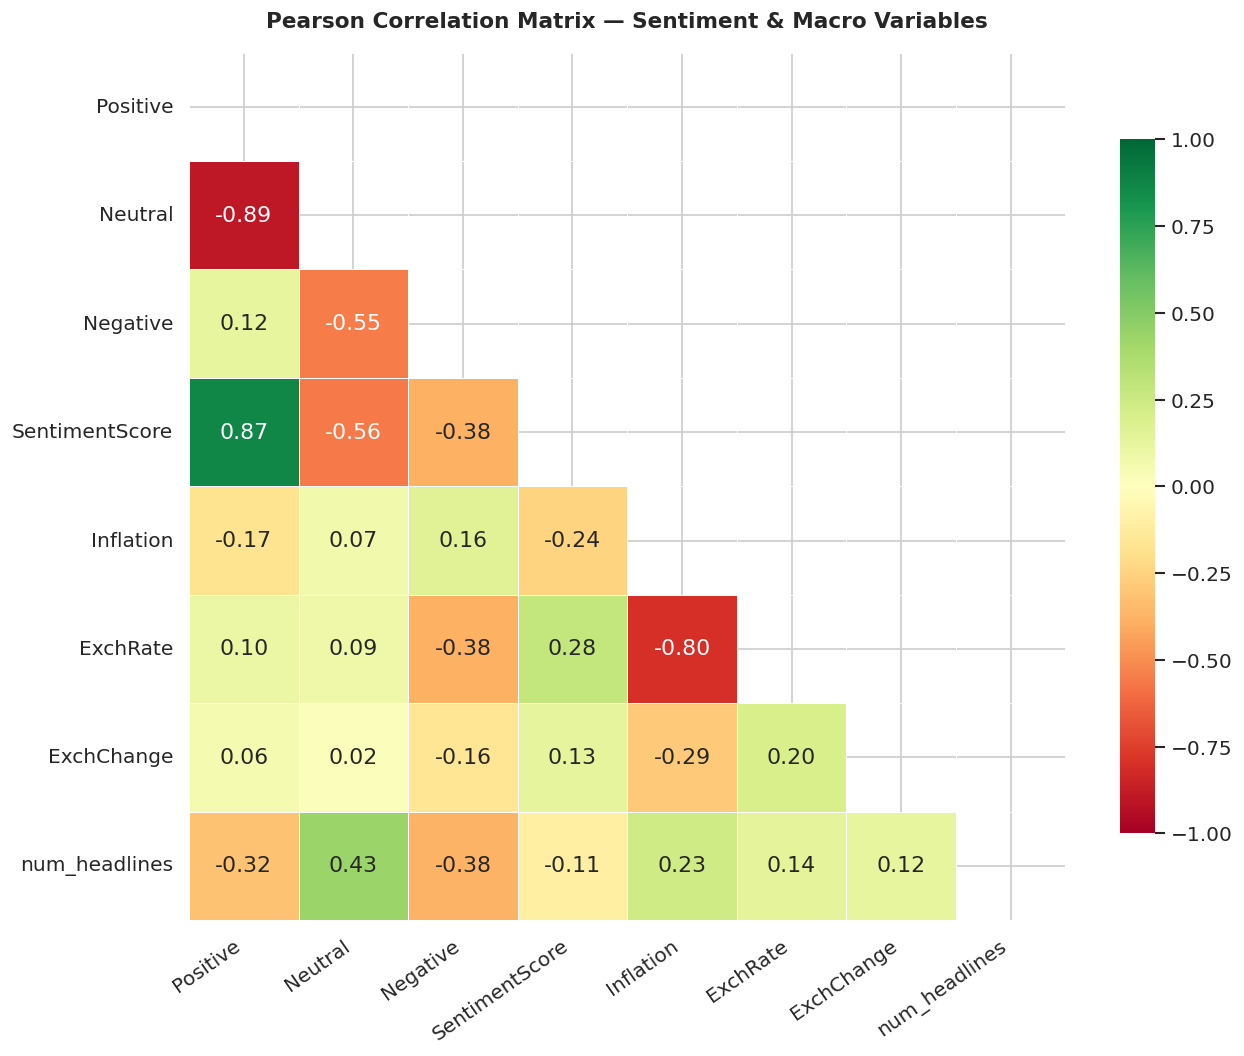

In [9]:
corr_cols = ['Positive', 'Neutral', 'Negative', 'SentimentScore',
             'Inflation', 'ExchRate', 'ExchChange', 'num_headlines']

corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Pearson Correlation Matrix — Sentiment & Macro Variables',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Scatter Regression — Sentiment Score vs. Key Indicators

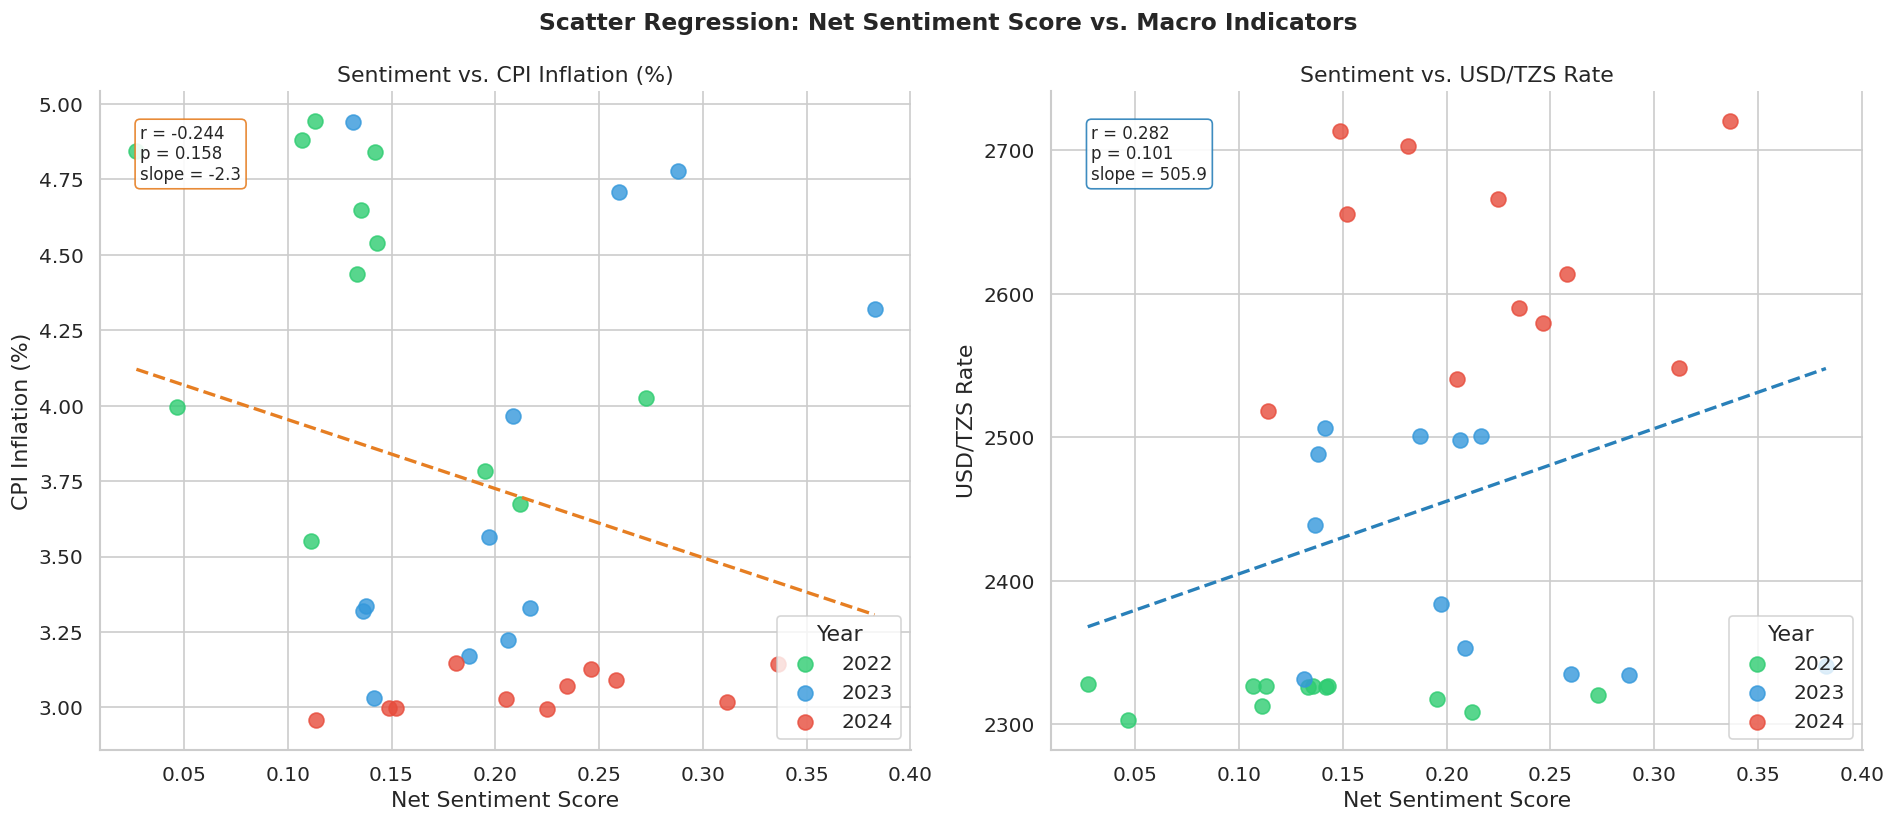

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Scatter Regression: Net Sentiment Score vs. Macro Indicators',
             fontsize=14, fontweight='bold')

for ax, y_col, y_label, color in [
    (axes[0], 'Inflation', 'CPI Inflation (%)', '#e67e22'),
    (axes[1], 'ExchRate',  'USD/TZS Rate',      '#2980b9')
]:
    x = df['SentimentScore'].values
    y = df[y_col].values

    # Color points by year
    year_colors = {2022: '#2ecc71', 2023: '#3498db', 2024: '#e74c3c'}
    for yr, ycol in year_colors.items():
        mask = df['Year'] == yr
        ax.scatter(df.loc[mask, 'SentimentScore'], df.loc[mask, y_col],
                   color=ycol, s=80, alpha=0.8, zorder=3, label=str(yr))

    # OLS regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept,
            color=color, lw=2, ls='--', zorder=4)

    # Annotation box
    ax.text(0.05, 0.95,
            f'r = {r_value:.3f}\np = {p_value:.3f}\nslope = {slope:.1f}',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor=color, alpha=0.9))

    ax.set_xlabel('Net Sentiment Score')
    ax.set_ylabel(y_label)
    ax.set_title(f'Sentiment vs. {y_label}')
    ax.legend(title='Year', loc='lower right')

plt.tight_layout()
plt.savefig('fig08_scatter_regression.png', bbox_inches='tight')
plt.show()

## 10. Yearly Summary — Year-on-Year Comparison

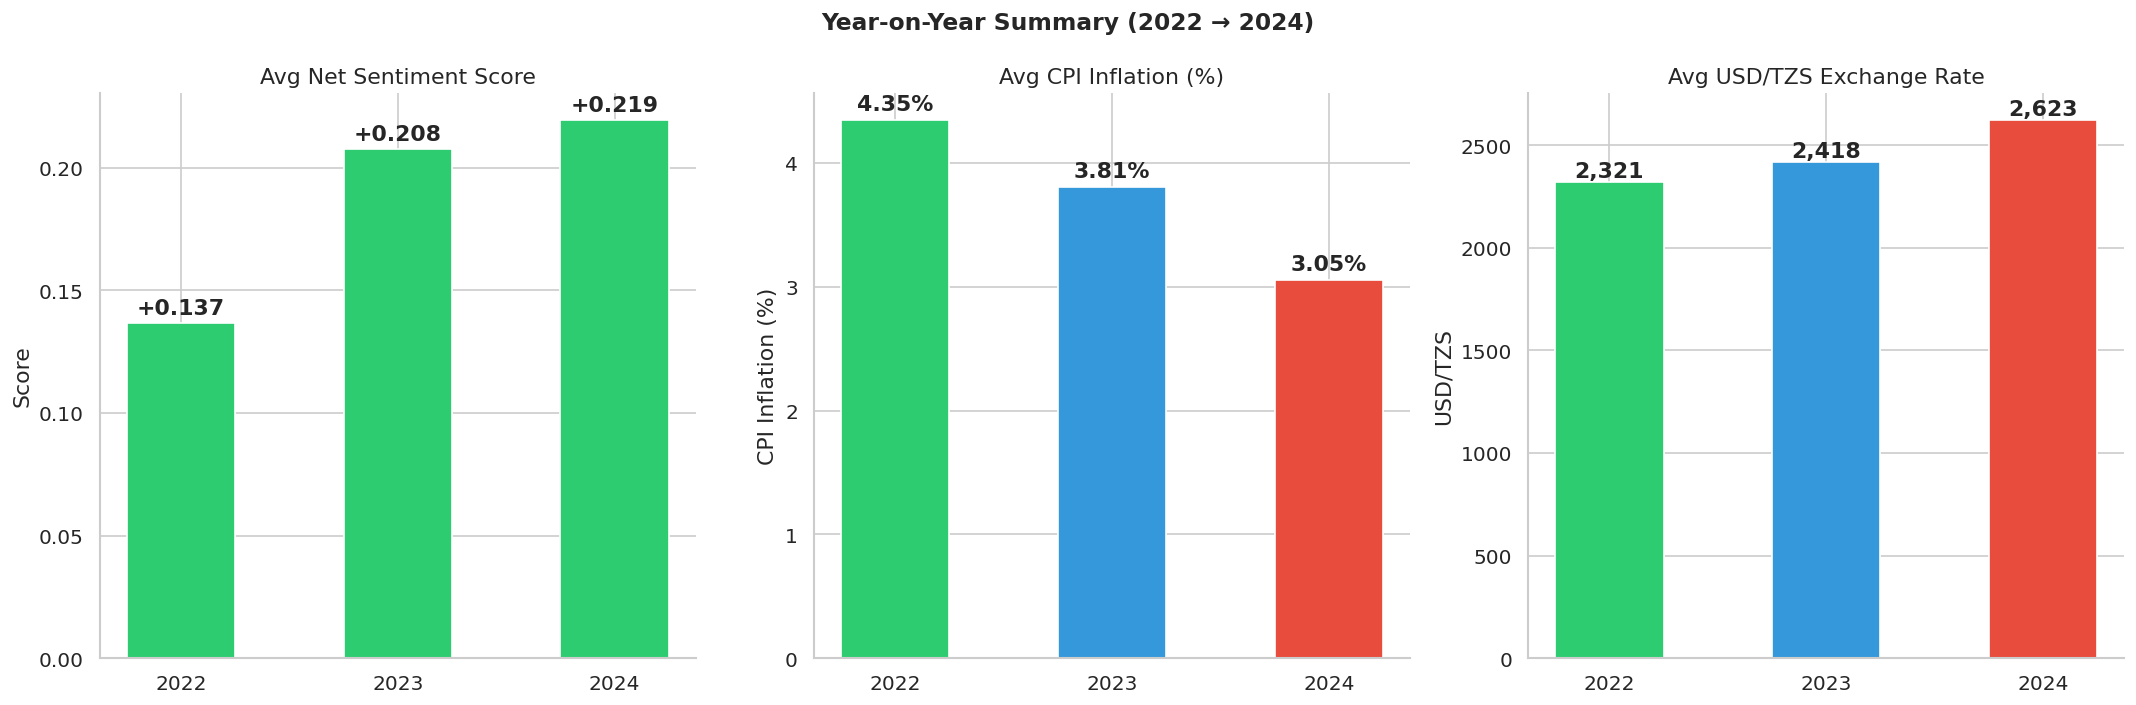

 Year  total_headlines  avg_positive  avg_neutral  avg_negative  avg_sentiment  avg_inflation  avg_exch
 2022             1078        23.884       65.882        10.233          0.137          4.347  2320.902
 2023             1536        27.965       64.847         7.189          0.208          3.807  2417.679
 2024             1162        28.411       65.114         6.476          0.219          3.052  2622.733


In [11]:
yearly = df.groupby('Year').agg(
    total_headlines=('num_headlines', 'sum'),
    avg_positive=('Positive', 'mean'),
    avg_neutral=('Neutral', 'mean'),
    avg_negative=('Negative', 'mean'),
    avg_sentiment=('SentimentScore', 'mean'),
    avg_inflation=('Inflation', 'mean'),
    avg_exch=('ExchRate', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Year-on-Year Summary (2022 → 2024)',
             fontsize=14, fontweight='bold')

years = yearly['Year'].astype(str)
year_colors = ['#2ecc71', '#3498db', '#e74c3c']

# ── 10a. Sentiment score per year ─────────────────────────────────────────
ax = axes[0]
bars = ax.bar(years, yearly['avg_sentiment'],
              color=[PALETTE['Positive'] if v >= 0 else PALETTE['Negative']
                     for v in yearly['avg_sentiment']],
              edgecolor='white', width=0.5)
ax.set_title('Avg Net Sentiment Score')
ax.set_ylabel('Score')
ax.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, yearly['avg_sentiment']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002 if val >= 0 else val - 0.005,
            f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontweight='bold')

# ── 10b. Inflation per year ────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(years, yearly['avg_inflation'],
              color=year_colors, edgecolor='white', width=0.5)
ax.set_title('Avg CPI Inflation (%)')
ax.set_ylabel('CPI Inflation (%)')
for bar, val in zip(bars, yearly['avg_inflation']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# ── 10c. Exchange rate per year ────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(years, yearly['avg_exch'],
              color=year_colors, edgecolor='white', width=0.5)
ax.set_title('Avg USD/TZS Exchange Rate')
ax.set_ylabel('USD/TZS')
for bar, val in zip(bars, yearly['avg_exch']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig09_yearly_summary.png', bbox_inches='tight')
plt.show()

print(yearly.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

## 11. Key Findings & Interpretation

In [12]:
# ── Compute final stats for the summary ───────────────────────────────────
r_infl, p_infl = pearsonr(df['SentimentScore'], df['Inflation'])
r_exch, p_exch = pearsonr(df['SentimentScore'], df['ExchRate'])
r_infl_sp, _ = spearmanr(df['SentimentScore'], df['Inflation'])
r_exch_sp, _ = spearmanr(df['SentimentScore'], df['ExchRate'])

neutral_pct = df['Neutral'].mean()
positive_pct = df['Positive'].mean()
negative_pct = df['Negative'].mean()
general_pct = (df['Top_Category'] == 'General').mean() * 100

print('=' * 60)
print('  EF-02 | KEY FINDINGS SUMMARY')
print('=' * 60)
print(f"""
SENTIMENT DISTRIBUTION
  Neutral  (avg): {neutral_pct:.1f}%   ← dominant across all months
  Positive (avg): {positive_pct:.1f}%
  Negative (avg): {negative_pct:.1f}%

  ⚠  Months with Neutral as dominant sentiment: {(df['Dominant_Sentiment']=='Neutral').sum()}/{len(df)}
  ⚠  Months where 'General' is top category:   {general_pct:.0f}% of all months
     → Implication: Many headlines may be too generic for
       domain-specific sentiment signals.

CORRELATION WITH MACROECONOMIC INDICATORS
  Sentiment ↔ CPI Inflation
    Pearson r  = {r_infl:+.3f}  (p = {p_infl:.3f}{'  ✓ significant' if p_infl < 0.05 else '  ✗ not significant'})
    Spearman ρ = {r_infl_sp:+.3f}

  Sentiment ↔ USD/TZS Exchange Rate
    Pearson r  = {r_exch:+.3f}  (p = {p_exch:.3f}{'  ✓ significant' if p_exch < 0.05 else '  ✗ not significant'})
    Spearman ρ = {r_exch_sp:+.3f}

INTERPRETATION
  • Negative r with exchange rate suggests that as TZS
    depreciates (higher USD/TZS), media tone slightly worsens.
  • The high neutral rate (avg ~65%) limits the signal strength.
    Reducing 'General' category noise and improving classifier
    precision could strengthen correlation findings.
  • The lag analysis (Fig. 5) reveals whether sentiment leads
    or follows economic changes — check the peak lag bar.

RECOMMENDATIONS FOR REPORT
  1. Flag 'General' as a data quality concern; propose
     re-categorisation of such headlines in future work.
  2. Acknowledge that Neutral dominance may reflect both
     genuine journalistic neutrality AND model limitations
     (TextBlob/early models underclassify financial text).
  3. Highlight Llama 3.3 70B (92% accuracy) as the
     recommended classifier going forward.
""")

  EF-02 | KEY FINDINGS SUMMARY

SENTIMENT DISTRIBUTION
  Neutral  (avg): 65.3%   ← dominant across all months
  Positive (avg): 26.7%
  Negative (avg): 8.0%

  ⚠  Months with Neutral as dominant sentiment: 34/35
  ⚠  Months where 'General' is top category:   69% of all months
     → Implication: Many headlines may be too generic for
       domain-specific sentiment signals.

CORRELATION WITH MACROECONOMIC INDICATORS
  Sentiment ↔ CPI Inflation
    Pearson r  = -0.244  (p = 0.158  ✗ not significant)
    Spearman ρ = -0.299

  Sentiment ↔ USD/TZS Exchange Rate
    Pearson r  = +0.282  (p = 0.101  ✗ not significant)
    Spearman ρ = +0.405

INTERPRETATION
  • Negative r with exchange rate suggests that as TZS
    depreciates (higher USD/TZS), media tone slightly worsens.
  • The high neutral rate (avg ~65%) limits the signal strength.
    Reducing 'General' category noise and improving classifier
    precision could strengthen correlation findings.
  • The lag analysis (Fig. 5) reveals wh